In [26]:
import gymnasium as gym
import ale_py
from stable_baselines3.common.atari_wrappers import AtariWrapper

gym.register_envs(ale_py)

env = gym.make("ALE/Pacman-v5")
env = AtariWrapper(env)

In [27]:
class PacmanRewardWrapper(gym.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.last_lives = 3

    def reward(self, reward):
        lives = self.env.unwrapped.ale.lives()

        penalty = 0
        if lives < self.last_lives:
            penalty = -50  # strong penalty for dying

        self.last_lives = lives

        return reward + penalty

In [28]:
model = PPO(
    "CnnPolicy",
    env,
    verbose=1,
    ent_coef=0.01,  # encourages randomness
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [29]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLogger(BaseCallback):
    def __init__(self, check_freq=1000):
        super().__init__()
        self.check_freq = check_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            print(f"Step: {self.num_timesteps}")
        return True

In [30]:
callback = RewardLogger()

model.learn(total_timesteps=1000000, callback=callback)

Step: 1000
Step: 2000
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24.6     |
|    ep_rew_mean     | 3.88     |
| time/              |          |
|    fps             | 87       |
|    iterations      | 1        |
|    time_elapsed    | 23       |
|    total_timesteps | 2048     |
---------------------------------
Step: 3000
Step: 4000
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.9        |
|    ep_rew_mean          | 4.22        |
| time/                   |             |
|    fps                  | 59          |
|    iterations           | 2           |
|    time_elapsed         | 69          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012750477 |
|    clip_fraction        | 0.101       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 

KeyboardInterrupt: 

In [32]:
from stable_baselines3.common.evaluation import evaluate_policy

mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)

C:\Users\ddoris\AppData\Local\anaconda3\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: 19.2
Std reward: 21.68317319951118


In [31]:
model.save("pacman_ppo5")

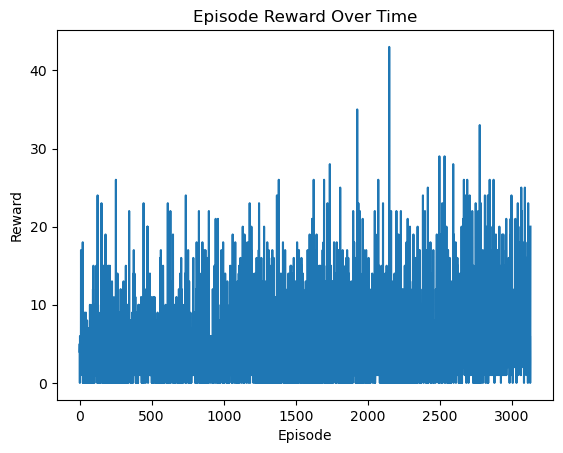

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("./logs.monitor.csv", skiprows=1)

# Plot rewards
plt.figure()
plt.plot(df["r"])
plt.title("Episode Reward Over Time")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

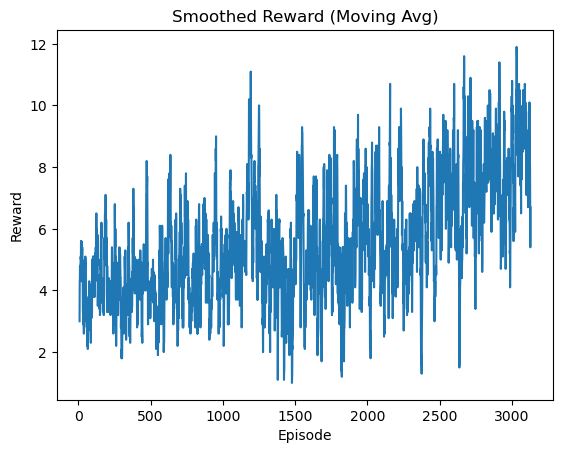

In [34]:
df["reward_smooth"] = df["r"].rolling(window=10).mean()

plt.figure()
plt.plot(df["reward_smooth"])
plt.title("Smoothed Reward (Moving Avg)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [1]:
env = gym.make("ALE/Pacman-v5", render_mode="human")
env = AtariWrapper(env)

from stable_baselines3 import PPO
model = PPO.load("pacman_ppo5.zip")

obs, _ = env.reset()

while True:
    action, _ = model.predict(obs)
    obs, _, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        obs, _ = env.reset()

NameError: name 'gym' is not defined